In [7]:
import pandas as pd

df = pd.read_csv("Dataset/Retail_Data_Transactions.csv")

df.head()

,customer_id,trans_date,tran_amount
0,CS5295,11-Feb-13,35
1,CS4768,15-Mar-15,39
2,CS2122,26-Feb-13,52
3,CS1217,16-Nov-11,99
4,CS1850,20-Nov-13,78


In [8]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

Number of Rows: 125000
Number of Columns: 3

Column Names:
['customer_id', 'trans_date', 'tran_amount']


In [10]:
df.isnull().sum()

customer_id    0
trans_date     0
tran_amount    0
dtype: int64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125000 entries, 0 to 124999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   customer_id  125000 non-null  object
 1   trans_date   125000 non-null  object
 2   tran_amount  125000 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 2.9+ MB


In [23]:
df['Year'] = df['trans_date'].dt.year
df['Month'] = df['trans_date'].dt.month_name()
df['Day'] = df['trans_date'].dt.day_name()

df.head()

,customer_id,trans_date,tran_amount,Year,Month,Day
0,CS5295,2013-02-11,35,2013,February,Monday
1,CS4768,2015-03-15,39,2015,March,Sunday
2,CS2122,2013-02-26,52,2013,February,Tuesday
3,CS1217,2011-11-16,99,2011,November,Wednesday
4,CS1850,2013-11-20,78,2013,November,Wednesday


In [24]:
total_revenue = df['tran_amount'].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 8123673


In [25]:
top_customers = (
    df.groupby('customer_id')['tran_amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_customers)

customer_id
CS4424    2933
CS4320    2647
CS5752    2612
CS4660    2527
CS3799    2513
CS5109    2506
CS4074    2462
CS3805    2453
CS4608    2449
CS5555    2439
Name: tran_amount, dtype: int64


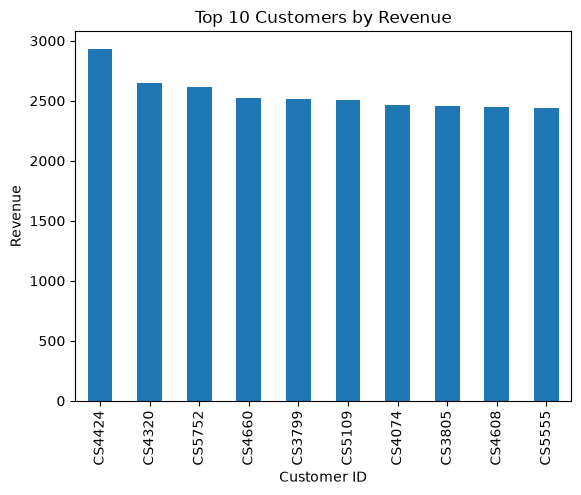

In [ ]:
import matplotlib.pyplot as plt

top_customers.plot(kind='bar')

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")

plt.show()

In [27]:
df.shape
df.info()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 124994 entries, 0 to 124999
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   customer_id  124994 non-null  object        
 1   trans_date   124994 non-null  datetime64[ns]
 2   tran_amount  124994 non-null  int64         
 3   Year         124994 non-null  int32         
 4   Month        124994 non-null  object        
 5   Day          124994 non-null  object        
dtypes: datetime64[ns](1), int32(1), int64(1), object(3)
memory usage: 6.2+ MB


np.int64(0)

In [21]:
df.duplicated().sum()

np.int64(6)

In [29]:
df.drop_duplicates(inplace=True)

print("Duplicates after cleaning:",
      df.duplicated().sum())

Duplicates after cleaning: 0


In [30]:
monthly_sales = (
    df.groupby('Month')['tran_amount']
      .sum()
      .sort_values(ascending=False)
)

monthly_sales

Month
August       726921
October      725272
January      724107
July         717207
December     709894
November     698273
June         697014
September    694366
February     645114
March        636502
May          633212
April        515791
Name: tran_amount, dtype: int64

In [31]:
yearly_sales = (
    df.groupby('Year')['tran_amount']
      .sum()
)

yearly_sales

Year
2011    1340291
2012    2116532
2013    2137352
2014    2094363
2015     435135
Name: tran_amount, dtype: int64

In [32]:
print(
    "Average Transaction Amount:",
    df['tran_amount'].mean()
)

Average Transaction Amount: 64.99250364017473


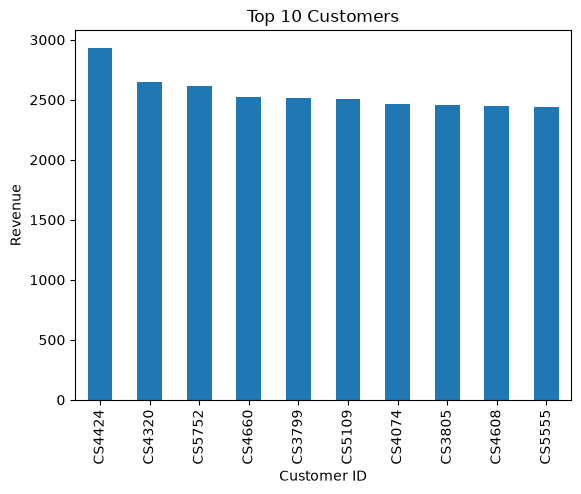

In [33]:
import matplotlib.pyplot as plt

top_customers.plot(kind='bar')

plt.title("Top 10 Customers")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")

plt.show()

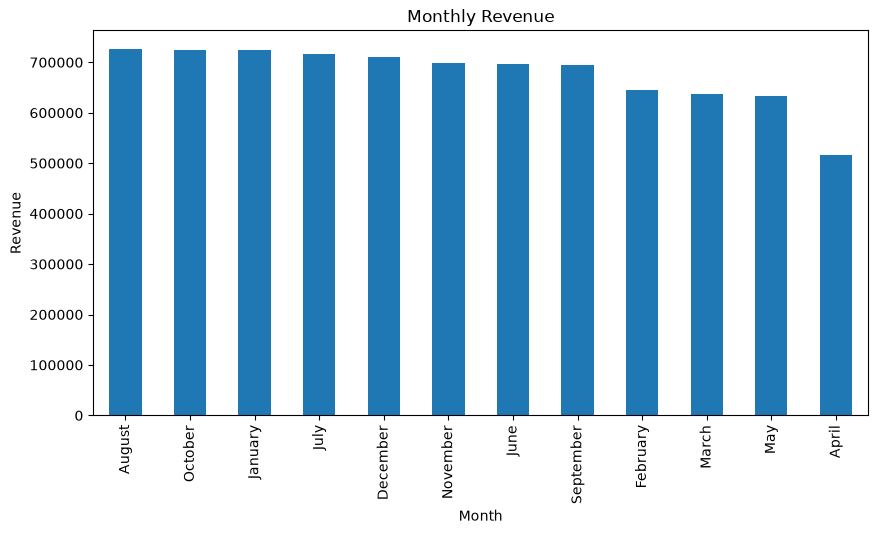

In [35]:
monthly_sales.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

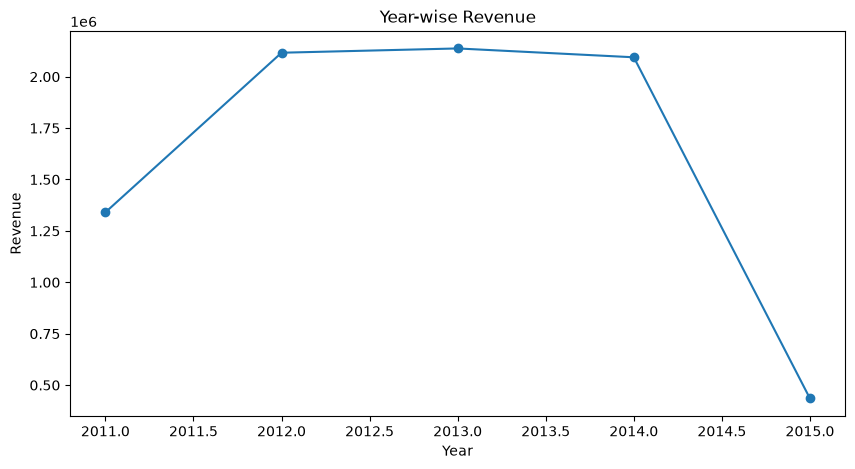

In [36]:
yearly_sales.plot(
    kind='line',
    marker='o',
    figsize=(10,5)
)

plt.title("Year-wise Revenue")
plt.xlabel("Year")
plt.ylabel("Revenue")

plt.show()

In [38]:
monthly_sales = df.groupby('Month')['tran_amount'].sum()
print(monthly_sales)

Month
April        515791
August       726921
December     709894
February     645114
January      724107
July         717207
June         697014
March        636502
May          633212
November     698273
October      725272
September    694366
Name: tran_amount, dtype: int64


In [39]:
yearly_sales = df.groupby('Year')['tran_amount'].sum()
print(yearly_sales)

Year
2011    1340291
2012    2116532
2013    2137352
2014    2094363
2015     435135
Name: tran_amount, dtype: int64


In [40]:
day_sales = df.groupby('Day')['tran_amount'].sum()
print(day_sales)

Day
Friday       1144028
Monday       1163285
Saturday     1164628
Sunday       1152393
Thursday     1159937
Tuesday      1168631
Wednesday    1170771
Name: tran_amount, dtype: int64


In [41]:
print(df['tran_amount'].mean())

64.99250364017473
